In [1]:
#Paqueting
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import re
import spacy
import nltk
import csv
from collections import Counter
from nltk.corpus import wordnet as wn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier


In [4]:
#Cosas en español
import spacy

!python -m spacy download es_core_news_sm

nltk.download('wordnet')
nltk.download('omw')
nlp = spacy.load("es_core_news_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 81.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw to /root/nltk_data...
[nltk_data]   Package omw is already up-to-date!


In [5]:
#Conectores discursivos a eliminar
con_disc = []
with open("/content/drive/MyDrive/conectores dfiscursivos.csv", newline='') as file:
    csv_reader = csv.reader(file)
    for f in csv_reader:
        con_disc.extend(f)

In [6]:
def limpiar(texto):
    if pd.isna(texto):
        return ""
    texto = texto.lower()
    texto = re.sub(r"\d+", "", texto)
    texto = re.sub(r"[^\w\s]", "", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    doc = nlp(texto)
    tokens = [
        token.lemma_ for token in doc
        if token.is_alpha
        and not token.is_stop
        and len(token.lemma_) > 2
        and token.pos_ != "VERB"
        and token.lemma_ not in con_disc
    ]

    return " ".join(tokens)

In [7]:
path = '/content/drive/MyDrive/c19-23-1011.xlsx'
dfo = pd.read_excel(path)
df = dfo.copy()

In [8]:
df = dfo.copy() #!!!Para reiniciar los datos

In [9]:
df["DESC_CAUSA_PROCESADO"] = df['DESC_CAUSA_CP'].apply(limpiar)

In [10]:
#Obtener las stopwords de las causas
pbr_contadas = Counter(" ".join(df["DESC_CAUSA_PROCESADO"]).split())
stop_propias = {word for word, count in pbr_contadas.items() if count > 0.075 * len(df)}
print(stop_propias)

{'seguimiento', 'indicador', 'dirección', 'operación', 'solicitud', 'programa', 'méxico', 'proyecto', 'personal', 'social', 'trimestre', 'evaluación', 'recurso', 'covid', 'centro', 'actividad', 'mes', 'meta', 'ciento', 'salud', 'investigación', 'cabo', 'registro', 'trabajo', 'anual', 'servicio', 'ajustado', 'entidad', 'sistema', 'derivado', 'desarrollo', 'periodo', 'unidad', 'proceso', 'diciembre', 'público', 'número', 'materia', 'programado', 'general', 'atención', 'porcentaje', 'resultado', 'nivel', 'año', 'federal', 'apoyo', 'cierre', 'avance', 'cumplimiento', 'establecido', 'aprobado', 'nacional', 'persona', 'fiscal', 'ejercicio', 'secretaría', 'acción', 'alcanzado', 'información', 'variación'}


###Sinónimos (no funciona para español)

In [ ]:
#!pip install spacy_wordnet
#from spacy_wordnet.wordnet_annotator import WordnetAnnotator

In [ ]:
'''def sin_fun(palabra):
    sinm = set()
    for synset in wn.synsets(palabra, lang="spa"):
        for lemma in synset.lemmas():
            sinm.add(lemma.name())
    return sinm

extra_stop = stopwords_propias.copy()
for palabra in stopwords_propias:
    extra_stop.update(sin_fun(palabra))'''

Stopwords refinadas con tesauro: {'intention', 'design', 'finishing_line', 'object', 'finish', 'aim', 'last', 'finish_line', 'finale', 'close', 'goal', 'meta', 'objective', 'stopping_point', 'intent', 'target', 'end', 'finis', 'conclusion', 'purpose'}


###Aprender

In [11]:
#Otras stop words
otras = ["año", "enero", "febrero", "marzo", "abril", "mayo", "junio", "agosto", "septiembre", "octubre", "noviembre", "diciembre", "programación", "ciclo", "méxico", "anual", "mensual", "ramo", "generado", "realizado", "registrado", "presupuestal", "presupuesto", "presupuestario"]

In [12]:
#Descargar las stopwords disponibles en español
nltk.download('stopwords')
stopword_es = nltk.corpus.stopwords.words('spanish')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [13]:
#Crear una lista de stopwords con las de la librería y las obtenidas
stop_propias = list(stop_propias)
stopwords = stopword_es + stop_propias + otras

In [14]:
#Limpiar ooooooooooooooootra vez con las stopwords que encontró en la primera limpieza :D
def limpiar(texto):
    if pd.isna(texto):
        return ""
    texto = texto.lower()
    texto = re.sub(r"\d+", "", texto)
    texto = re.sub(r"[^\w\s]", "", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    texto = ' '.join([palabra for palabra in texto.split() if palabra not in stopwords])
    return texto


In [15]:
df["DESC_CAUSA_PROCESADO"] = df['DESC_CAUSA_PROCESADO'].apply(limpiar)

In [16]:
X = df['DESC_CAUSA_PROCESADO']
y = df['KA_META_TIPO_JUST_DOCUMENTO']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2000)

vectorizer = TfidfVectorizer(stop_words=stopwords)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

clf = RandomForestClassifier(class_weight='balanced',n_estimators=100, random_state=2000)
clf.fit(X_train_tfidf, y_train)

y_pred = clf.predict(X_test_tfidf)

print(classification_report(y_test, y_pred,zero_division=1))

df_grouped = df.groupby('KA_META_TIPO_JUST_DOCUMENTO')['DESC_CAUSA_PROCESADO'].apply(' '.join).reset_index()
X_grouped = vectorizer.transform(df_grouped['DESC_CAUSA_PROCESADO'])


terms = vectorizer.get_feature_names_out()

for idx, row in df_grouped.iterrows():
    tfidf_scores = X_grouped[idx, :].toarray().flatten()
    word_score_pairs = [(terms[i], tfidf_scores[i]) for i in range(len(terms))]
    sorted_word_score_pairs = sorted(word_score_pairs, key=lambda x: x[1], reverse=True)
    top_keywords = [pair[0] for pair in sorted_word_score_pairs[:10]]

    print(f"KA_META: {df_grouped.iloc[idx]['KA_META_TIPO_JUST_DOCUMENTO']}")
    print(f"Palabras: {', '.join(top_keywords)}\n")

              precision    recall  f1-score   support

           1       0.51      0.22      0.31       100
           2       0.69      0.42      0.52       237
           3       0.67      0.35      0.46       182
           4       1.00      0.20      0.33        10
           5       1.00      0.28      0.43        54
           6       0.75      0.17      0.27        18
           7       0.92      0.71      0.80       191
           8       0.88      0.30      0.45        70
           9       0.64      0.58      0.61      2489
          10       0.62      0.75      0.68      2848
          11       0.69      0.71      0.70      2369
          12       0.71      0.31      0.43       103

    accuracy                           0.65      8671
   macro avg       0.76      0.42      0.50      8671
weighted avg       0.66      0.65      0.65      8671

KA_META: 1
Palabras: mir, cálculo, educación, control, base, ejecución, construcción, económico, sectorial, agua

KA_META: 2
Palabras

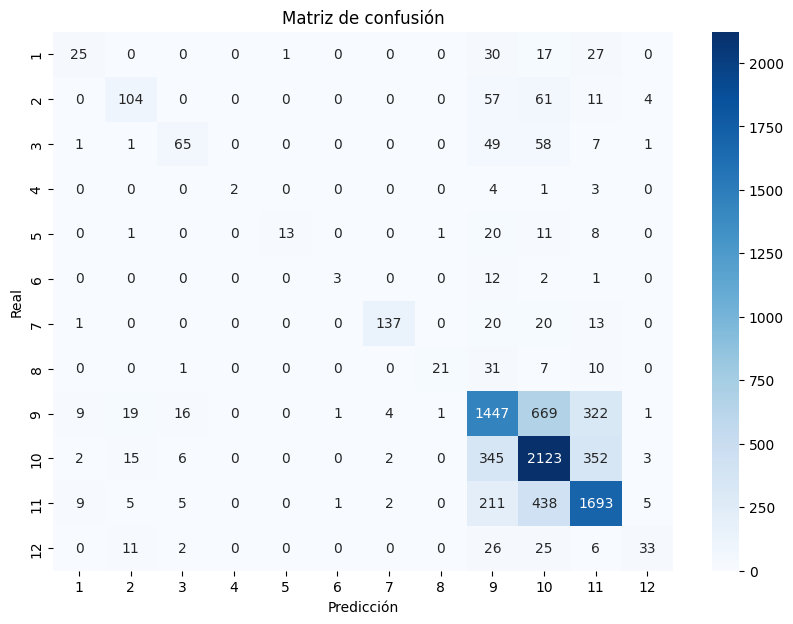

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(y), yticklabels=set(y))
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()


### Similitud

In [ ]:
#Modificar y aplicar las palabras con el mejor resultado

In [17]:
KA_DESC = ["Programación original deficiente", "Emergencias provocadas por accidentes y/o fenómenos naturales adversos", "Menor demanda de bienes y servicios", "Retrasos en los trámites para el ejercicio presupuestario por parte de la Unidad Responsable (UR)", "Incumplimiento o retraso en los trámites para el ejercicio presupuestario por parte de instancias gubernamentales diferentes a la UR.","Incumplimiento o inconformidades de proveedores y contratistas, así como por oposición de grupos sociales", "Modificación de atribuciones institucionales por disposiciones normativas", "Incumplimiento por situaciones normativas extrapresupuestarias ajenas a la UR", "Otras causas que por su naturaleza no es posible agrupar", "Otras explicaciones a las variaciones, cuando se trate de resultados por encima del 100 por ciento de cumplimiento", "La meta del indicador del desempeño fue cumplida", "Emergencias sanitarias"]

In [18]:
df_grouped = df.groupby('KA_META_TIPO_JUST_DOCUMENTO')['DESC_CAUSA_PROCESADO'].apply(' '.join).reset_index()

In [19]:
texto_completo = KA_DESC + df_grouped['DESC_CAUSA_PROCESADO'].tolist()

In [20]:
X = vectorizer.fit_transform(texto_completo)

In [21]:
cosine_similarities = cosine_similarity(X[:len(KA_DESC)], X[len(KA_DESC):])
resultados_similitud = []

In [22]:
for idx, causa in enumerate(df_grouped['DESC_CAUSA_PROCESADO']):
    ka_idx = df_grouped['KA_META_TIPO_JUST_DOCUMENTO'][idx] - 1
    ka_desc = KA_DESC[ka_idx]
    causa_vector = vectorizer.transform([causa])
    ka_desc_vector = vectorizer.transform([ka_desc])
    similitud = cosine_similarity(causa_vector, ka_desc_vector)[0][0]
    resultados_similitud.append({
        "KA_META_TIPO_JUST_DOCUMENTO": df_grouped['KA_META_TIPO_JUST_DOCUMENTO'][idx],
        "DESC_CAUSA_PROCESADO": causa,
        "KA_DESC": ka_desc,
        "Similitud": similitud
    })


In [23]:
df_resultados = pd.DataFrame(resultados_similitud)

In [24]:
print(df_resultados)

    KA_META_TIPO_JUST_DOCUMENTO  \
0                             1   
1                             2   
2                             3   
3                             4   
4                             5   
5                             6   
6                             7   
7                             8   
8                             9   
9                            10   
10                           11   
11                           12   

                                 DESC_CAUSA_PROCESADO  \
0   ajuste programada omisión numerador valor real...   
1   integridad estabilidad independencia soberanía...   
2   ingreso compuesto venta orden ingreso diverso ...   
3   evidencia comite ética prevención conflicto in...   
4   estudio superior naval cantidad matricula inst...   
5   obra rescisión contrato calzado nivelación vía...   
6   absorción presidencial reincorporándolo origen...   
7   numero reforma ley código reglamento principal...   
8   objetivo inhibición área re

In [26]:
df_resultados.to_excel('/content/drive/MyDrive/output1.xlsx')